## `Task` Select best features from from Wine Quality dataset.

* Data Link : https://www.kaggle.com/datasets/rajyellow46/wine-quality

* Drive link : https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv

Note : Follow approach from Feature Selection Session - 2

In [63]:
# Your Code goes Here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv")

In [3]:
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
df['type'].value_counts()

type
white    4898
red      1599
Name: count, dtype: int64

In [5]:
df.shape

(6497, 13)

In [28]:
df =  df.dropna(axis=0)

In [26]:
100*(6497-6463)/6497

0.5233184546713868

In [30]:
df.isna().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [32]:
# 1 - Exhaustive Feature Selection
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

# training a logestic machine learning module
lr = LogisticRegression()

In [33]:
#splitting a data
x_train = df.iloc[:,1:]
y_train = df.iloc[:,0]


In [ ]:
efs = EFS(lr,max_features = 12,scoring='accuracy',cv=5)

In [ ]:
model = efs.fit(x_train,y_train)

In [36]:
#2 - Sequential Backword Elimination

In [ ]:
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.preprocessing import LabelEncoder

# Encode target labels
le = LabelEncoder()
x = df.iloc[:,1:]
y = le.fit_transform(df.iloc[:,0])


In [54]:
# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
print(X_train.shape)


(5170, 12)


In [55]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [56]:
# Baseline Model
from sklearn.metrics import r2_score
model = LogisticRegression()

print("training",np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test, y_test, cv=5, scoring='r2')))

training 0.9645186738274157
testing 0.9751125099127677


In [72]:
lr = LogisticRegression()

# perform backward elimination
sfs = SFS(lr, k_features=8, forward=False, floating=False, scoring='r2',cv=5)

sfs.fit(X_train, y_train)

,estimator,LogisticRegression()
,k_features,"(8, ...)"
,forward,False
,floating,False
,verbose,0
,scoring,'r2'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [73]:
sfs.k_feature_idx_

(0, 1, 3, 5, 6, 7, 10, 11)

In [74]:
def adjust_r2(r2, num_examples, num_features):
    coef = (num_examples - 1) / (num_examples - num_features - 1)
    return 1 - (1 - r2) * coef

In [75]:
metric_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T

metric_df['observations'] = 404
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x:len(x))
metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'],metric_df['observations'],metric_df['num_features'])

metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
12,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.9634665859075308, 0.9530284675953967, 0.953...",0.964519,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.014958,0.011638,0.005819,404,12,0.96343
11,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11)","[0.9634665859075308, 0.9530284675953967, 0.963...",0.964524,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11)",0.008923,0.006943,0.003471,404,11,0.963529
10,"(0, 1, 2, 3, 5, 6, 7, 8, 10, 11)","[0.9739047042196649, 0.9530284675953967, 0.968...",0.968699,"(0, 1, 2, 3, 5, 6, 7, 8, 10, 11)",0.010404,0.008094,0.004047,404,10,0.967903
9,"(0, 1, 2, 3, 5, 6, 7, 10, 11)","[0.9739047042196649, 0.9530284675953967, 0.968...",0.968699,"(0, 1, 2, 3, 5, 6, 7, 10, 11)",0.010404,0.008094,0.004047,404,9,0.967984
8,"(0, 1, 3, 5, 6, 7, 10, 11)","[0.9739047042196649, 0.9530284675953967, 0.968...",0.968699,"(0, 1, 3, 5, 6, 7, 10, 11)",0.010404,0.008094,0.004047,404,8,0.968066


In [76]:
metric_df.sort_values('adjusted_r2',ascending=False)

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
8,"(0, 1, 3, 5, 6, 7, 10, 11)","[0.9739047042196649, 0.9530284675953967, 0.968...",0.968699,"(0, 1, 3, 5, 6, 7, 10, 11)",0.010404,0.008094,0.004047,404,8,0.968066
9,"(0, 1, 2, 3, 5, 6, 7, 10, 11)","[0.9739047042196649, 0.9530284675953967, 0.968...",0.968699,"(0, 1, 2, 3, 5, 6, 7, 10, 11)",0.010404,0.008094,0.004047,404,9,0.967984
10,"(0, 1, 2, 3, 5, 6, 7, 8, 10, 11)","[0.9739047042196649, 0.9530284675953967, 0.968...",0.968699,"(0, 1, 2, 3, 5, 6, 7, 8, 10, 11)",0.010404,0.008094,0.004047,404,10,0.967903
11,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11)","[0.9634665859075308, 0.9530284675953967, 0.963...",0.964524,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11)",0.008923,0.006943,0.003471,404,11,0.963529
12,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.9634665859075308, 0.9530284675953967, 0.953...",0.964519,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.014958,0.011638,0.005819,404,12,0.96343


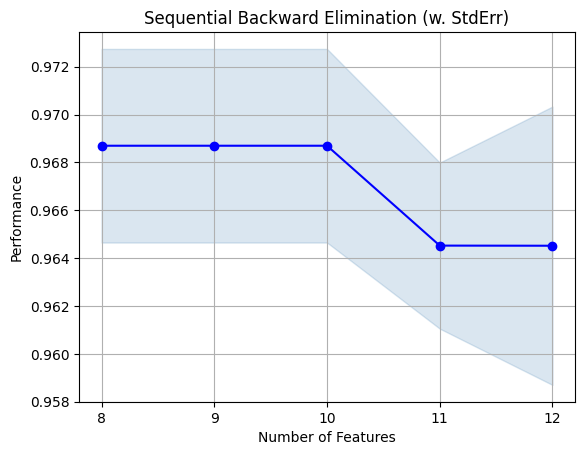

In [77]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs


fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_err',)

plt.title('Sequential Backward Elimination (w. StdErr)')
plt.grid()
plt.show()

In [78]:
X_train_sel = sfs.transform(X_train)
X_test_sel = sfs.transform(X_test)

model = LogisticRegression()

print("training",np.mean(cross_val_score(model, X_train_sel, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test_sel, y_test, cv=5, scoring='r2')))

training 0.9686994385447172
testing 0.9751605868358446
